In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report
)

dataset = load_breast_cancer()
X = dataset.data
y = dataset.target

print('Features shape:', X.shape)
print('Classes distribution:', np.bincount(y))


Features shape: (569, 30)
Classes distribution: [212 357]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [9]:
acc = accuracy_score(y_test,y_pred)
print("accuracy score: ", acc)

prec = precision_score(y_test,y_pred)
print("precision score: ", prec)

recall = recall_score(y_test,y_pred)
print("recall score: ", recall)

f1 = f1_score(y_test,y_pred)
print("f1 score: ", f1)

print('Full Classification report---')
print(classification_report(y_test,y_pred, target_names=dataset.target_names))



accuracy score:  0.9736842105263158
precision score:  0.9722222222222222
recall score:  0.9859154929577465
f1 score:  0.9790209790209791
Full Classification report---
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



confusion_matrix
[[41  2]
 [ 1 70]]


<Figure size 600x500 with 0 Axes>

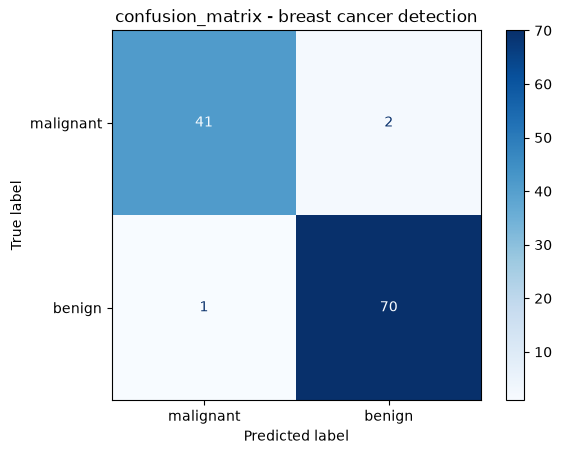

In [10]:
cm = confusion_matrix(y_test, y_pred)
print("confusion_matrix")
print(cm)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.target_names)
disp.plot(cmap="Blues")
plt.title("confusion_matrix - breast cancer detection")
plt.show()